# Benchmarks ran in an RTX4070 GPU

In [ ]:
from benchmarks import generate_benchmark_data

generate_benchmark_data("timings.csv")

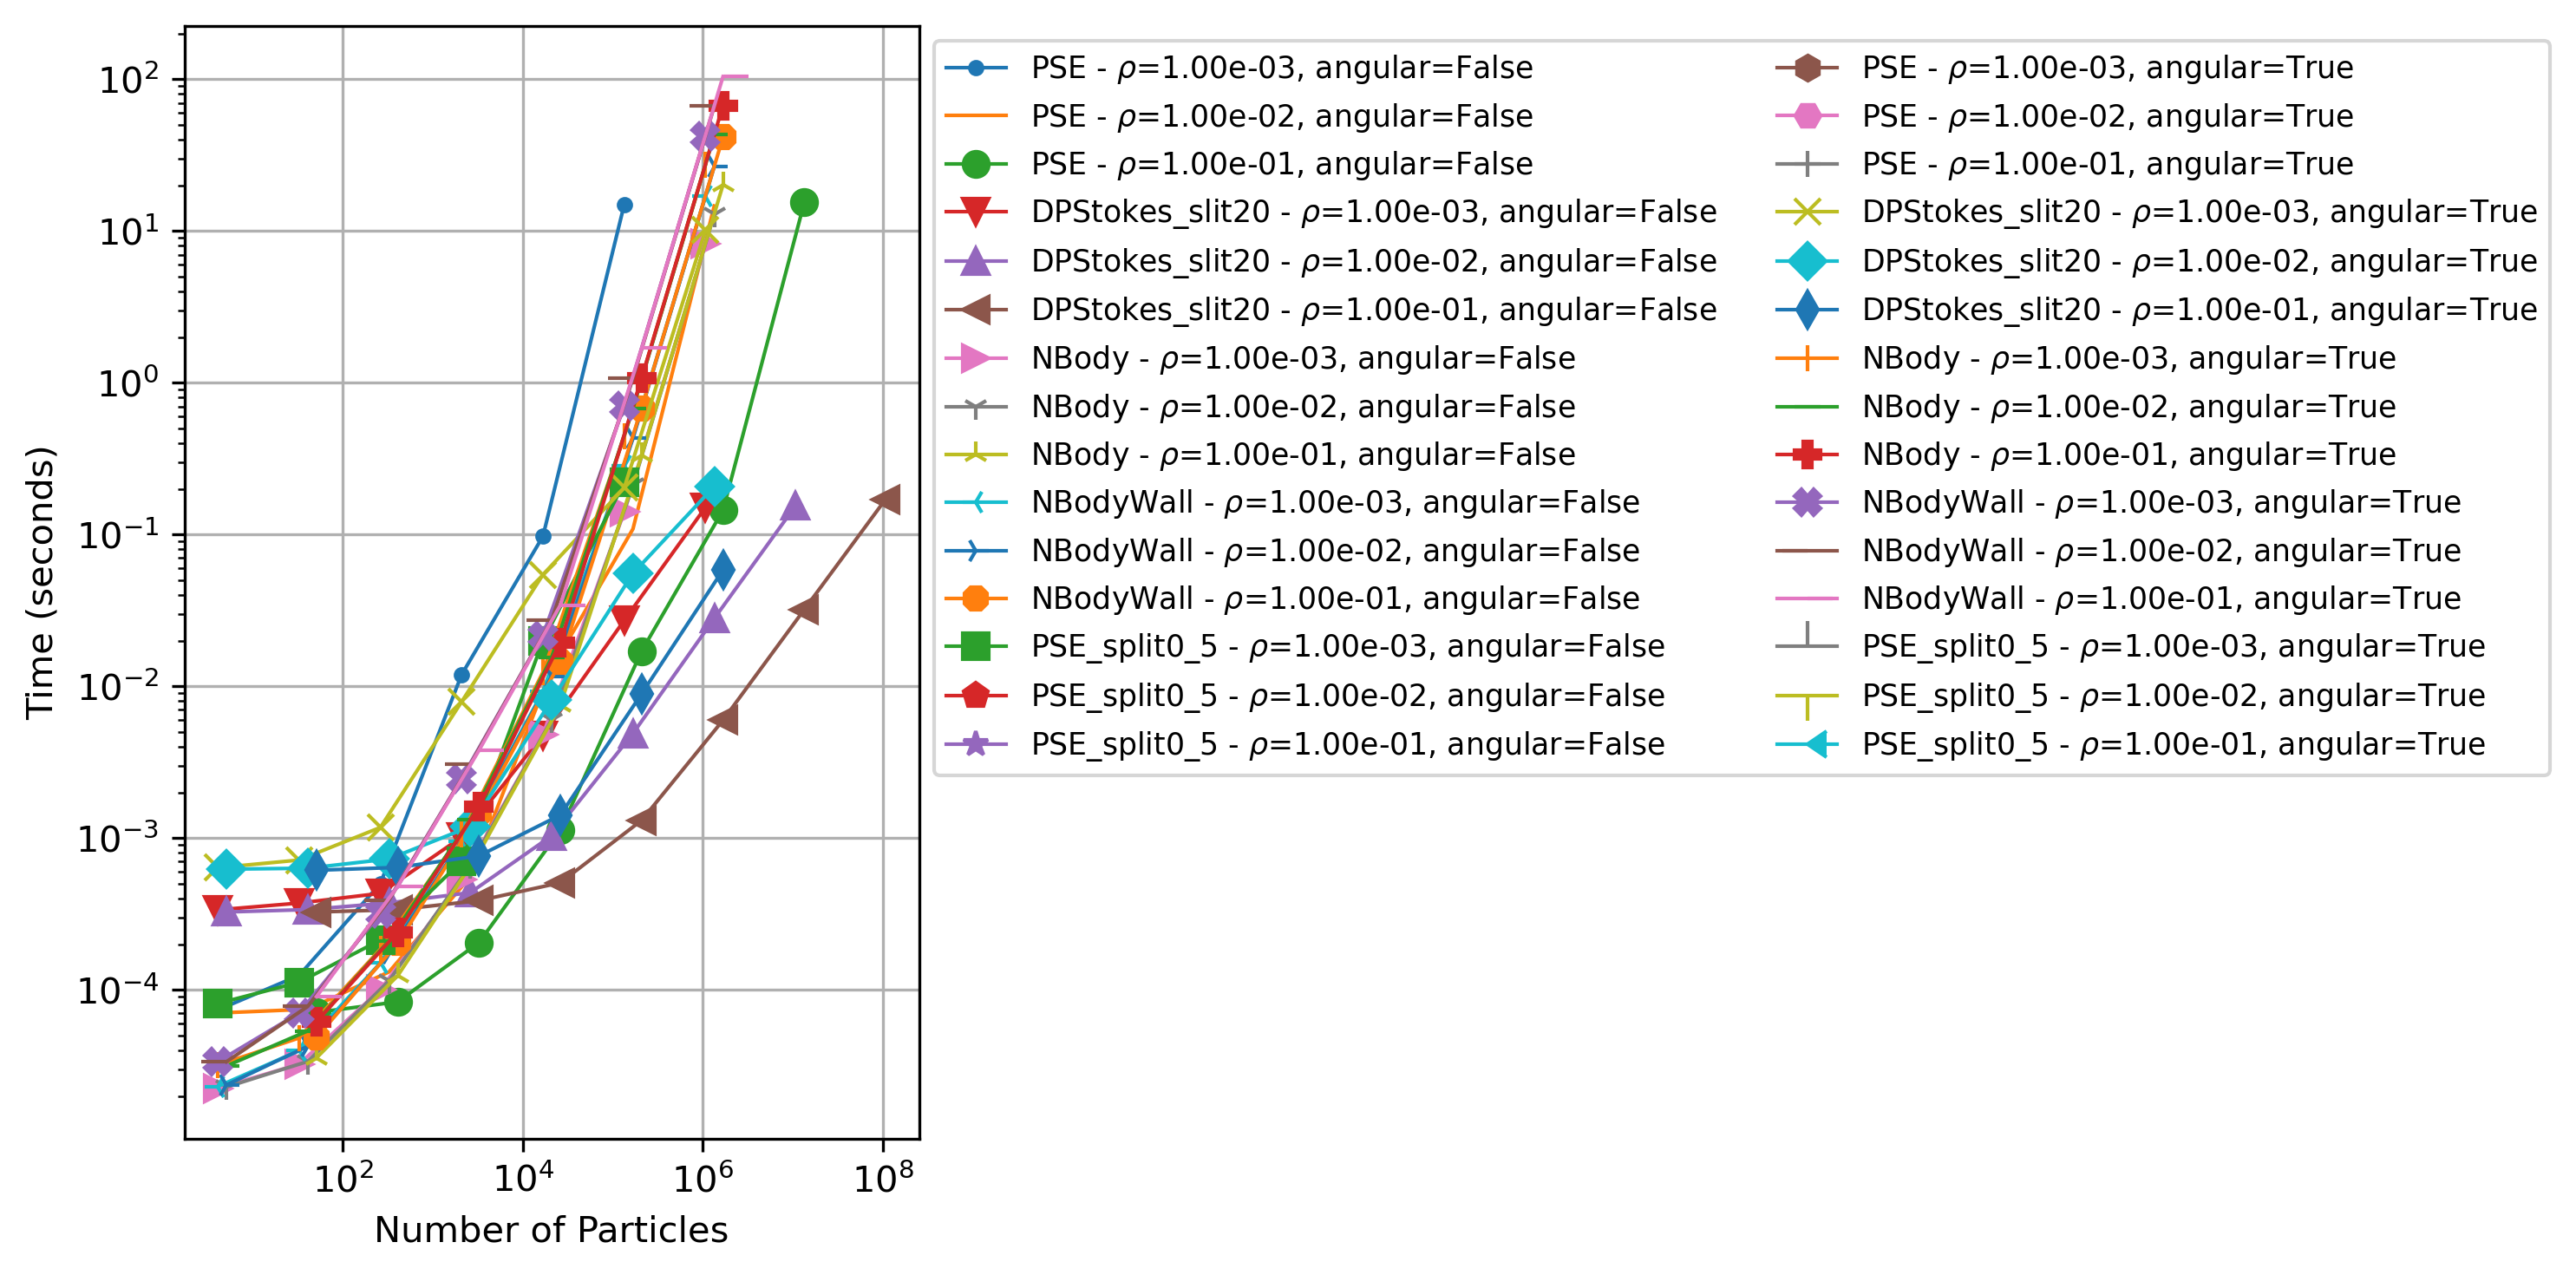

In [10]:
import matplotlib.markers
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.markers
df = pd.read_csv("timings.csv")
# Drop times that are zero or negative
df = df[df['time_deterministic'] > 0]
plt.figure(figsize=(10, 5))
#Increase outptut resolution
plt.rcParams['figure.dpi'] = 300
# Plot a line x**2
t = np.logspace(4, 6, 100)
#plt.plot(t,5e-8*t, 'k--', label='N', linewidth =1)
#plt.plot(t,1e-11*t**2, 'k-', label='N**2', linewidth =1)
marker_idx = 0
markers = list(matplotlib.markers.MarkerStyle.markers.keys())
for angular in df['includes_angular'].unique():
    for solver in df['solver'].unique():
        for density in df['density'].unique():
            subset = df[(df['solver'] == solver) & (df['density'] == density) & (df['includes_angular'] == angular)]
            subset = subset.sort_values(by='box_size')
            lbox = [float(x) for x in subset['box_size']]
            nparticles = [density*l**3 for l in lbox]
            rho_symbol = r"$\rho$"
            plt.plot(nparticles, subset['time_deterministic'],
                label=f"{solver} - {rho_symbol}={density:.2e}, angular={angular}", marker=markers[marker_idx], markersize=7, linewidth=1)
            marker_idx += 1
            if marker_idx >= len(markers):
                marker_idx = 0

plt.xlabel("Number of Particles")
plt.ylabel("Time (seconds)")
# Make the legend multicolumn
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), ncol=2, fontsize='small')
plt.xscale('log')
plt.yscale('log')
plt.grid(True)
plt.tight_layout()
plt.show()